In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')

# player list
players = pd.read_csv('../data/player_list.csv')
print("Player list loaded!")
print(players[['name_english', 'tier', 'signing_year']])

Player list loaded!
     name_english          tier  signing_year
0    Chan Ho Park  1A_Sustained          1994
1  Byung-Hyun Kim       1B_Peak          1997
2   Shin-Soo Choo  1A_Sustained          2001
3     Ji Hwan Bae         2_Mid          2018
4     Ji-Man Choi         2_Mid          2010
5       Jung Bong         2_Mid          1997
6     Won-Bin Cho    3_Prospect          2022
7   Seong-Jun Kim    3_Prospect          2025
8     Seojun Moon      4_Newest          2025


In [4]:
mlb_era_data = pd.DataFrame({
    'year': list(range(1994, 2026)),
    'avg_fastball_mph': [
        89.0, 89.2, 89.3, 89.5, 89.7, 89.8, 90.0, 90.1, 90.2, 90.3,
        90.5, 90.7, 91.0, 91.2, 91.5, 91.8, 92.0, 92.3, 92.5, 92.8,
        93.0, 93.3, 93.5, 93.7, 93.9, 94.0, 94.1, 94.2, 94.3, 94.4,
        94.5, 94.6
    ],
    'league_era': [
        4.51, 4.44, 4.60, 4.56, 4.58, 4.71, 4.77, 4.42, 4.28, 4.40,
        4.40, 4.29, 4.53, 4.47, 4.32, 4.32, 3.86, 3.94, 4.01, 3.87,
        3.74, 4.01, 4.19, 4.36, 4.15, 4.45, 4.40, 4.26, 4.32, 4.30,
        4.28, 4.25
    ],
    'league_k_per_9': [
        5.94, 6.06, 6.36, 6.42, 6.55, 6.57, 6.47, 6.53, 6.56, 6.55,
        6.56, 6.39, 6.65, 6.73, 6.77, 7.06, 7.07, 7.10, 7.51, 7.73,
        7.68, 7.71, 8.12, 8.24, 8.48, 8.81, 8.73, 8.58, 8.50, 8.45,
        8.40, 8.38
    ]
})

# 시대 구분 추가
def get_era(year):
    if year <= 2003:
        return 'Steroid Era'
    elif year <= 2007:
        return 'Post-Steroid'
    elif year <= 2013:
        return 'Analytics Revolution'
    elif year <= 2019:
        return 'Modern/Pitch Design'
    else:
        return 'Current'

mlb_era_data['era_label'] = mlb_era_data['year'].apply(get_era)

# 선수 활동 시기 표시
mlb_era_data['park_active'] = mlb_era_data['year'].between(1994, 2010)
mlb_era_data['kim_active'] = mlb_era_data['year'].between(1999, 2007)
mlb_era_data['choo_active'] = mlb_era_data['year'].between(2005, 2020)

print("MLB era data created!")
print(f"기간: {mlb_era_data['year'].min()} - {mlb_era_data['year'].max()}")
print(f"\n시대 구분:")
print(mlb_era_data.groupby('era_label')['year'].agg(['min', 'max']))

MLB era data created!
기간: 1994 - 2025

시대 구분:
                       min   max
era_label                       
Analytics Revolution  2008  2013
Current               2020  2025
Modern/Pitch Design   2014  2019
Post-Steroid          2004  2007
Steroid Era           1994  2003


차트 저장 완료!


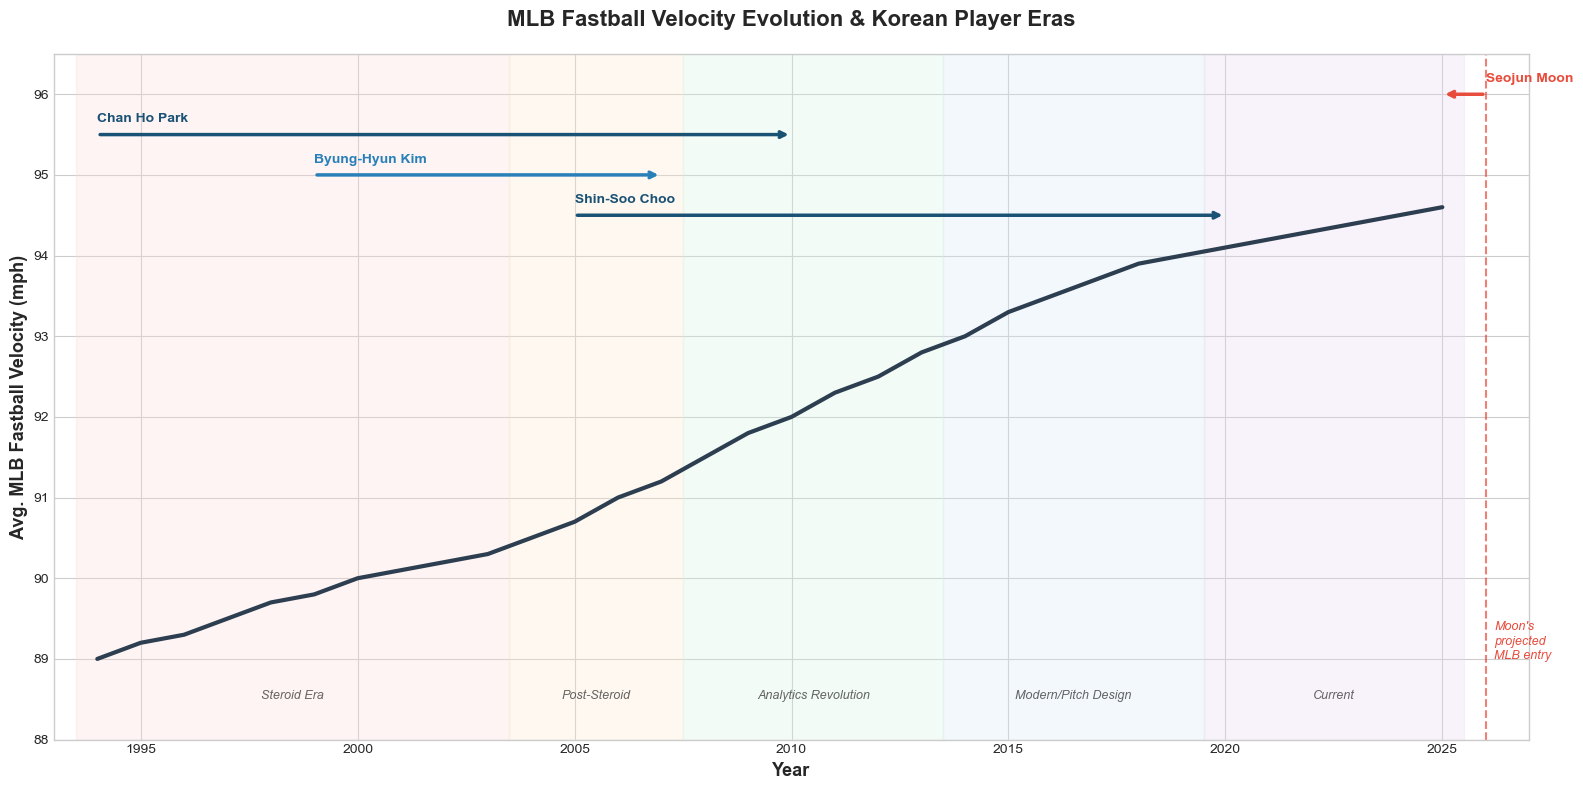

In [5]:
fig, ax = plt.subplots(figsize=(16, 8))

# 패스트볼 구속 변화 선 그래프
ax.plot(mlb_era_data['year'], mlb_era_data['avg_fastball_mph'], 
        color='#2c3e50', linewidth=3, zorder=3)

# 시대 구분 배경색
era_colors = {
    'Steroid Era': '#fadbd8',
    'Post-Steroid': '#fdebd0', 
    'Analytics Revolution': '#d5f5e3',
    'Modern/Pitch Design': '#d6eaf8',
    'Current': '#e8daef'
}

for era_name, era_color in era_colors.items():
    era_years = mlb_era_data[mlb_era_data['era_label'] == era_name]['year']
    if len(era_years) > 0:
        ax.axvspan(era_years.min() - 0.5, era_years.max() + 0.5, 
                   alpha=0.3, color=era_color, zorder=1)
        mid_year = (era_years.min() + era_years.max()) / 2
        ax.text(mid_year, 88.5, era_name, ha='center', fontsize=9, 
                fontstyle='italic', alpha=0.7)

# 한국 선수 활동 기간 화살표로 표시
players_timeline = [
    ('Chan Ho Park', 1994, 2010, 95.5, '#1a5276'),
    ('Byung-Hyun Kim', 1999, 2007, 95.0, '#2980b9'),
    ('Shin-Soo Choo', 2005, 2020, 94.5, '#1a5276'),
    ('Seojun Moon', 2026, 2030, 96.0, '#e74c3c'),
]

for name, start, end, y_pos, color in players_timeline:
    # 활동 기간 막대
    ax.annotate('', xy=(min(end, 2025), y_pos), xytext=(start, y_pos),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    
    # 선수 이름
    ax.text(start, y_pos + 0.15, name, fontsize=10, fontweight='bold', 
            color=color)

# 문서준 예상 진입 시점 강조
ax.axvline(x=2026, color='#e74c3c', linestyle='--', alpha=0.7, linewidth=1.5)
ax.text(2026.2, 89.0, "Moon's\nprojected\nMLB entry", fontsize=9, 
        color='#e74c3c', fontstyle='italic')

# 축 설정
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg. MLB Fastball Velocity (mph)', fontsize=13, fontweight='bold')
ax.set_title('MLB Fastball Velocity Evolution & Korean Player Eras', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlim(1993, 2027)
ax.set_ylim(88, 96.5)

plt.tight_layout()
plt.savefig('../visualizations/03_era_velocity_timeline.png', dpi=150, bbox_inches='tight')
print("차트 저장 완료!")
plt.show()

차트 저장 완료!


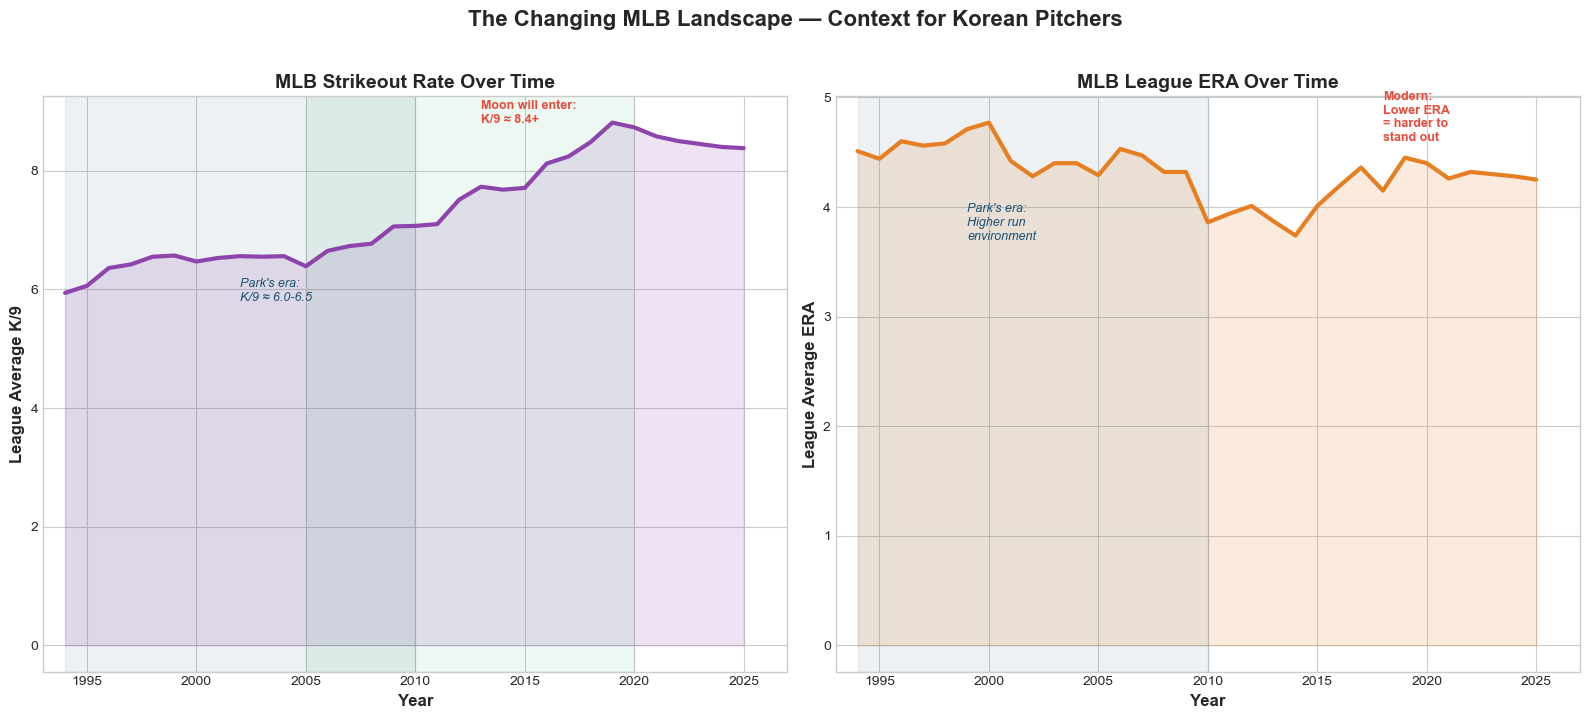

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# 좌: 삼진율 변화
ax1.plot(mlb_era_data['year'], mlb_era_data['league_k_per_9'], 
         color='#8e44ad', linewidth=3)
ax1.fill_between(mlb_era_data['year'], mlb_era_data['league_k_per_9'], 
                 alpha=0.15, color='#8e44ad')

# 선수별 활동 기간 강조
ax1.axvspan(1994, 2010, alpha=0.08, color='#1a5276')  # 박찬호
ax1.axvspan(2005, 2020, alpha=0.08, color='#27ae60')  # 추신수

ax1.text(2002, 5.8, "Park's era:\nK/9 ≈ 6.0-6.5", fontsize=9, 
         color='#1a5276', fontstyle='italic')
ax1.text(2013, 8.8, "Moon will enter:\nK/9 ≈ 8.4+", fontsize=9, 
         color='#e74c3c', fontweight='bold')

ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel('League Average K/9', fontsize=12, fontweight='bold')
ax1.set_title('MLB Strikeout Rate Over Time', fontsize=14, fontweight='bold')
ax1.set_xlim(1993, 2027)

# 우: ERA 변화
ax2.plot(mlb_era_data['year'], mlb_era_data['league_era'], 
         color='#e67e22', linewidth=3)
ax2.fill_between(mlb_era_data['year'], mlb_era_data['league_era'], 
                 alpha=0.15, color='#e67e22')

ax2.axvspan(1994, 2010, alpha=0.08, color='#1a5276')
ax2.text(1999, 3.7, "Park's era:\nHigher run\nenvironment", fontsize=9, 
         color='#1a5276', fontstyle='italic')
ax2.text(2018, 4.6, "Modern:\nLower ERA\n= harder to\nstand out", fontsize=9, 
         color='#e74c3c', fontweight='bold')

ax2.set_xlabel('Year', fontsize=12, fontweight='bold')
ax2.set_ylabel('League Average ERA', fontsize=12, fontweight='bold')
ax2.set_title('MLB League ERA Over Time', fontsize=14, fontweight='bold')
ax2.set_xlim(1993, 2027)

plt.suptitle('The Changing MLB Landscape — Context for Korean Pitchers', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visualizations/04_k_rate_era_evolution.png', dpi=150, bbox_inches='tight')
print("차트 저장 완료!")
plt.show()

## Era-Adjusted Analysis: Key Findings

### 1. Velocity Inflation
- When Chan Ho Park debuted (1994), the average MLB fastball was ~89 mph.
  His mid-90s velocity was elite.
- When Seojun Moon enters (2026+), the average will be ~94.5 mph.
  His 90-95 mph range is merely average — he must differentiate through
  pitch mix, movement, and command.

### 2. Strikeout Environment
- Park pitched in a K/9 ~6.0 era. Generating strikeouts was less common
  and therefore less expected.
- Moon will enter a K/9 ~8.4+ environment. Strikeout ability is now baseline,
  not a differentiator.

### 3. Strategic Implication for Moon
- In Park's era, velocity alone could create an advantage.
- In Moon's era, success requires: elite secondary pitches (slider, changeup),
  pitch design optimization, and an ability to evolve repertoire over time.
- Moon's 4-pitch mix (FB, SL, CB, CH) is a strength — development should
  focus on making 2-3 of these plus pitches rather than relying on velocity.